In [19]:
%pip install matplotlib numpy pandas scikit-learn 

Note: you may need to restart the kernel to use updated packages.


## Conceitos de Classificação

Dados: Dataset MNIST-784, que contem 70000 imagens preto em brancas de tamanho 28x28, ou seja, flated temos 784 features (pixeis que variam de 0 a 255), já vem preprocessado e separado.

In [20]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [21]:
X, y = mnist.data,mnist.target

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

(70000, 784)
(70000,)


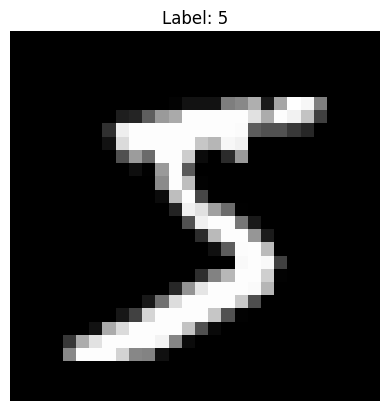

In [22]:
from matplotlib import pyplot as plt

plt.imshow(X[0].reshape(28, 28), cmap='gray') 
# reshape para transformar o vetor de 784 pixels em uma imagem 28x28, e cmap='gray' para exibir a imagem em escala de cinza.

plt.title(f"Label: {y[0]}")
plt.axis('off')
plt.show()

### Classificação Binária

Podemos por simplicidade treinar um modelo de classificação binária em queremos classificar se o digito é 7 ou não é 7... teremos apenas essas 2 opções. 

In [ ]:
y_train_7 =  (y_train == '7')
y_test_7 =  (y_test == '7') # geramos vetores target booleanos 

from sklearn.linear_model import SGDClassifier

sgdclass_model = SGDClassifier(random_state=42) # muito util para grandes datasets, pois processa os dados em mini-batches, 
#o que reduz o uso de memória e pode acelerar o treinamento. Além disso, util em treino online pois pode ser atualizado com 
# novos dados sem precisar ser re-treinado do zero.
# Stocastic -> atualiza os pesos do modelo para cada amostra de treinamento
# Batch -> atualiza os pesos do modelo apenas após processar todo o conjunto de treinamento
# Mini-batch -> atualiza os pesos do modelo após processar um pequeno lote de amostras de treinamento (mini-batch)

sgdclass_model.fit(X_train, y_train_7)

print(sgdclass_model.predict(X[10:30]))
print(y[10:30])


[False False False False False  True False False False False False False
 False False False False False False False  True]
['3' '5' '3' '6' '1' '7' '2' '8' '6' '9' '4' '0' '9' '1' '1' '2' '4' '3'
 '2' '7']


Métricas:

ValueError: Found array with dim 3, while dim <= 2 is required by SGDClassifier.